# Baseline CNN

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

### 1. Import libraries

In [2]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

os.chdir(ROOT)
print(Path.cwd())

/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use Cuda else MPS

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


### 3. Split Dataset 
- Use simpleCNN model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
)


model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

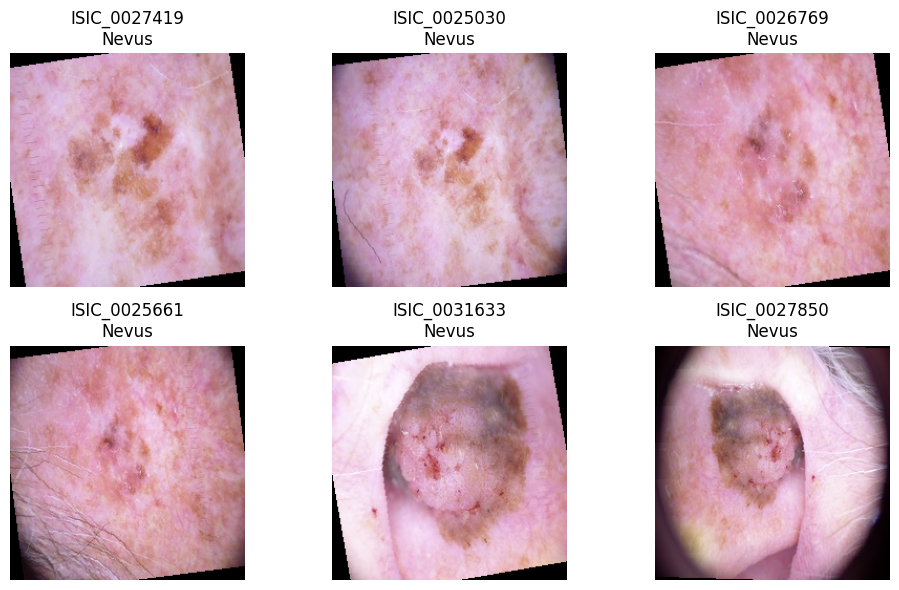

In [5]:
import matplotlib.pyplot as plt
import numpy as np

label_map = {0: "Nevus", 1: "Melanoma"}

def imshow(img_tensor):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

dataset = train_loader.dataset

plt.figure(figsize=(10, 6))

for i in range(6):
    image, label = dataset[i]
    image_id = dataset.data.iloc[i]["image_id"]

    plt.subplot(2, 3, i + 1)
    plt.imshow(imshow(image))
    plt.title(f"{image_id}\n{label_map[label]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4. Train Model

In [6]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 0.3496, Train Acc: 0.8893 | Val Loss: 0.3011, Val Acc: 0.8834


Epoch [2/20] | Train Loss: 0.3052, Train Acc: 0.8901 | Val Loss: 0.3200, Val Acc: 0.8834


Epoch [3/20] | Train Loss: 0.2857, Train Acc: 0.8901 | Val Loss: 0.3064, Val Acc: 0.8834


Epoch [4/20] | Train Loss: 0.2806, Train Acc: 0.8913 | Val Loss: 0.2760, Val Acc: 0.8834


Epoch [5/20] | Train Loss: 0.2732, Train Acc: 0.8900 | Val Loss: 0.2914, Val Acc: 0.8839


...

Epoch [16/20] | Train Loss: 0.2198, Train Acc: 0.9079 | Val Loss: 0.2769, Val Acc: 0.8908


Epoch [17/20] | Train Loss: 0.2120, Train Acc: 0.9089 | Val Loss: 0.2909, Val Acc: 0.8898


Epoch [18/20] | Train Loss: 0.2064, Train Acc: 0.9144 | Val Loss: 0.2753, Val Acc: 0.8933


Epoch [19/20] | Train Loss: 0.2037, Train Acc: 0.9173 | Val Loss: 0.3024, Val Acc: 0.8898


Epoch [20/20] | Train Loss: 0.1975, Train Acc: 0.9158 | Val Loss: 0.2973, Val Acc: 0.8898


### 5. Plot Loss and Accuracy Curves

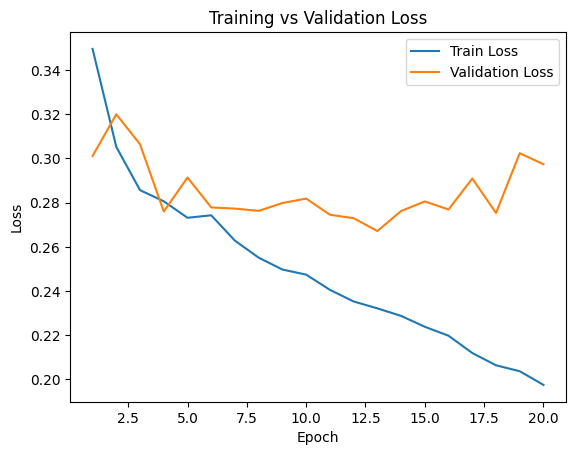

In [7]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

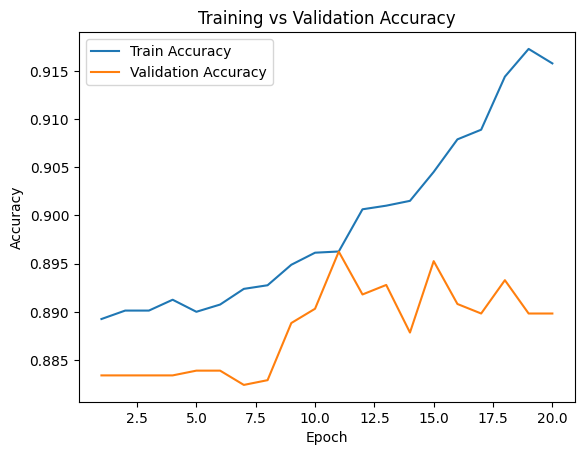

In [8]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [9]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.5)            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [10]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1289   51]
 [ 123   48]]


In [11]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9129    0.9619    0.9368      1340
           1     0.4848    0.2807    0.3556       171

    accuracy                         0.8848      1511
   macro avg     0.6989    0.6213    0.6462      1511
weighted avg     0.8644    0.8848    0.8710      1511



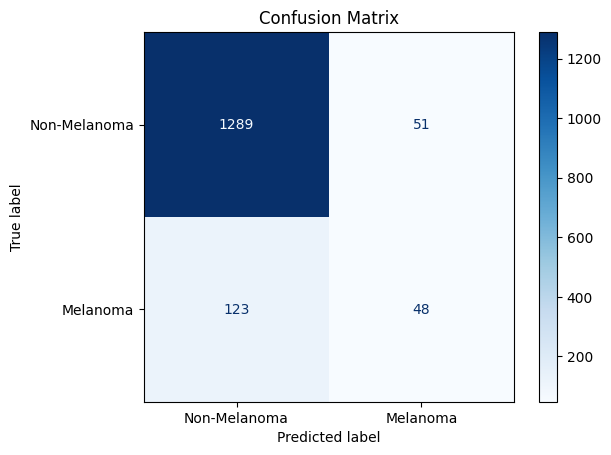

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

- The baseline CNN shows signs of mild overfitting.
- Training loss decreases steadily from 0.3496 to 0.1975 over 20 epochs, while training accuracy improves from 88.93% to 91.58%, indicating that the model is able to learn the training data. 
- However, validation performance improves only in the earlier epochs: validation loss reaches its lowest value around epoch 13 (0.2672) and validation accuracy peaks around epoch 11 (89.62%), before fluctuating and slightly worsening toward the end. 
- This divergence between continued training improvement and stagnant or degrading validation performance suggests that the model begins to overfit after roughly epoch 11 to 13.

- Although the overall test accuracy is 88.48%, the model detects melanoma poorly, with recall of only 28.07% and F1-score of 0.3556. This means the CNN is learning general patterns, but it is biased toward the majority non-melanoma class and fails to generalize well on the minority melanoma class. 